In [ ]:
from gensim.models import Word2Vec
from transformers import T5Tokenizer, T5ForConditionalGeneration
import torch

from torch import nn
import numpy as np
import datasets
from datasets import DatasetDict
from sklearn.model_selection import train_test_split
import pandas

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

c:\Users\victo\anaconda3\envs\exam\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In this file we try to find a linear embedding transformation matrix that can transform our GloVe or Word2Vec embeddings that have been trained on unlabelled Cantonese data to MADLAD's embedding space using Cantonese->Mandarin translations from Gatitos. 

In [2]:
# credit to https://stackoverflow.com/a/38230349
def load_glove_model(File):
    print("Loading Glove Model")
    glove_model = {}
    with open(File,'r') as f:
        for line in f:
            split_line = line.split()
            word = split_line[0]
            embedding = np.array(split_line[1:], dtype=np.float64)
            glove_model[word] = embedding
    print(f"{len(glove_model)} words loaded!")
    return glove_model

glove_model = load_glove_model("vectors.txt")

Loading Glove Model
18237 words loaded!


In [ ]:

#word2vec_model = Word2Vec.load("./unlabelled/10_epoch_embeddings_long_sentences.model")
#word2vec_model = Word2Vec.load("./unlabelled/character_embeddings_6epoch.model")

model_name = 'jbochi/madlad400-3b-mt'
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

madlad_embeddings = torch.load("madlad_embedding.pth")

C:\Users\victo\AppData\Local\Temp\ipykernel_11476\784929123.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  madlad_embeddings = torch.load("madlad_embedding.pth")


In [5]:
def madlad_tokenize(word):
    return [tokenizer.decode(x) for x in tokenizer(word)["input_ids"] if x != 2 and x != 805]

In [ ]:
gatitos: DatasetDict = datasets.load_dataset("google/smol", "gatitos__yue_zh") # type: ignore

token_translations: list[dict[str, list[str]]] = []
for i in range(gatitos['train']['src'].__len__()): 
    for s in gatitos['train']['src'][i].split('; '):
        #if np.all([x in word2vec_model.wv for x in madlad_tokenize(s)]):
        if np.all([x in glove_model.keys() for x in madlad_tokenize(s)]):
            for t in gatitos['train']['trgs'][i]:
                token_translations.append({
                    'src': s,
                    'trg': t
                })

In [65]:
batch_size = 64

In [75]:
class GatitosDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
    
    def __len__(self):
        return self.dataset.__len__()
    
    def __getitem__(self, idx):
        return self.dataset[idx]["src"], self.dataset[idx]["trg"]


train_data, validation_data = train_test_split(token_translations, train_size=0.9, random_state=0, shuffle=True)
train_data, test_data = train_test_split(train_data, train_size=8/9, random_state=0, shuffle=False)

train_data = GatitosDataset(train_data)
validation_data = GatitosDataset(validation_data)
test_data = GatitosDataset(test_data)

gatitos_train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
gatitos_validation_dataloader = DataLoader(validation_data, batch_size=batch_size, shuffle=True)
gatitos_test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [100]:

madlad_norm = torch.mean(torch.tensor([torch.norm(x) for x in madlad_embeddings["weight"]]))
glove_norm = torch.mean(torch.tensor([torch.norm(torch.tensor(glove_model[x])) for x in glove_model.keys()]))

In [ ]:
epochs = 10
lr = 10**-2 
train_losses=[]
test_losses=[]

from tqdm.notebook import tqdm

W = torch.randn(1024, 1024, requires_grad=True, device=device)
optim = torch.optim.Adam([W], lr=lr)

In [101]:

def get_madlad_embedding_layer():
    return madlad_embeddings # decoder and encoder uses the same embedding weights
get_madlad_embedding_layer()["weight"].dtype

torch.float32

In [102]:
def get_madlad_embedding(token: str, include_start_and_end_tokens=False) -> torch.Tensor:
    '''
    [:, -1, :] is the EOF token embedding
    '''
    input_ids = tokenizer(token, return_tensors="pt").input_ids
    
    if not include_start_and_end_tokens:
        input_ids = input_ids[input_ids != 2]
        input_ids = input_ids[input_ids != 805]
    
    embeddings = get_madlad_embedding_layer()["weight"][input_ids] / madlad_norm
    
    return embeddings


start_token = (get_madlad_embedding(''))
embedding = get_madlad_embedding('<2en>')

embedding.shape, start_token.shape

(torch.Size([1, 1024]), torch.Size([0, 1024]))

In [15]:
def mean_embedding_word2vec(chars, model):
    return torch.mean(torch.tensor([model.wv[char] for char in chars]), dim=0)

In [103]:
def mean_embedding_glove(chars, model):
    return torch.mean(torch.tensor(np.array([model[char] for char in chars])), dim=0).to(torch.float32) / glove_norm

In [ ]:

def criterion(X, W, Y): 
    pred = X @ W
    targets = Y
    diff = torch.norm(pred - targets,dim=1)
    loss = diff @ diff

    return loss

for epoch in range(epochs):
    epoch_loss = 0
    batch_sizes = []
    lengths = []

    for batch in gatitos_train_dataloader:
        cantonese_sentences, mandarin_sentences = batch
        mandarin_embeddings = torch.stack([torch.mean(get_madlad_embedding(mandarin_sentences[x]),dim=0) for x in range(len(mandarin_sentences))]).to(device)
        #cantonese_embeddings = torch.stack([mean_embedding_word2vec(madlad_tokenize(cantonese_sentences[x]), word2vec_model) for x in range(len(cantonese_sentences))]).to(device)
        cantonese_embeddings = torch.stack([mean_embedding_glove(madlad_tokenize(cantonese_sentences[x]), glove_model) for x in range(len(cantonese_sentences))]).to(device)
        cantonese_embeddings = cantonese_embeddings.to(torch.float32)
        lengths.append(len(cantonese_sentences))
        
        optim.zero_grad()
        loss = criterion(cantonese_embeddings, W, mandarin_embeddings)  + torch.norm(W) ** 2 * 1e-2 / (1024**2)

        loss.backward()
        optim.step()
        #epoch_loss += (loss.item() - torch.norm(W.detach().cpu()) ** 2 * 1e-3 / (1024**2))
    
    #epoch_loss = epoch_loss / np.sum(lengths)
    #train_losses.append(epoch_loss)

    
    train_step_losses = []
    if epoch % 1 == 0:
        lengths = []
        for batch in gatitos_train_dataloader:
            cantonese_sentences, mandarin_sentences = batch
            mandarin_embeddings = torch.stack([torch.mean(get_madlad_embedding(mandarin_sentences[x]),dim=0) for x in range(len(mandarin_sentences))]).to(device)
            #cantonese_embeddings = torch.stack([mean_embedding_word2vec(madlad_tokenize(cantonese_sentences[x]), word2vec_model) for x in range(len(cantonese_sentences))]).to(device)
            cantonese_embeddings = torch.stack([mean_embedding_glove(madlad_tokenize(cantonese_sentences[x]), glove_model) for x in range(len(cantonese_sentences))]).to(device)
            cantonese_embeddings = cantonese_embeddings.to(torch.float32)

            lengths.append(len(cantonese_sentences))
            loss = criterion(cantonese_embeddings, W, mandarin_embeddings).detach().cpu() 
            train_step_losses.append(loss / len(cantonese_sentences))

            epoch_loss += loss

        epoch_loss = epoch_loss / np.sum(lengths)
        train_losses.append(epoch_loss)
    
    

    test_step_losses = []
    if epoch % 1 == 0:
        test_loss = 0
        lengths = []
        for batch in gatitos_validation_dataloader:
            cantonese_sentences, mandarin_sentences = batch
            mandarin_embeddings = torch.stack([torch.mean(get_madlad_embedding(mandarin_sentences[x]),dim=0) for x in range(len(mandarin_sentences))]).to(device)
            #cantonese_embeddings = torch.stack([mean_embedding_word2vec(madlad_tokenize(cantonese_sentences[x]), word2vec_model) for x in range(len(cantonese_sentences))]).to(device)
            cantonese_embeddings = torch.stack([mean_embedding_glove(madlad_tokenize(cantonese_sentences[x]), glove_model) for x in range(len(cantonese_sentences))]).to(device)
            cantonese_embeddings = cantonese_embeddings.to(torch.float32)

            lengths.append(len(cantonese_sentences))

            loss = criterion(cantonese_embeddings, W, mandarin_embeddings).detach().cpu() 
            test_loss += loss 

            test_step_losses.append(loss / len(cantonese_sentences))

        
        test_loss = test_loss / np.sum(lengths)
        print(f"{epoch:3d}: train loss: {epoch_loss:.5f}, validation loss: {test_loss:.5f}")
        test_losses.append(test_loss)

  0: train loss: 0.74736, validation loss: 0.97688
  1: train loss: 0.80063, validation loss: 1.02904
  2: train loss: 0.78236, validation loss: 1.00784
  3: train loss: 0.86469, validation loss: 1.08213
  4: train loss: 0.75342, validation loss: 0.97107


In [171]:
torch.norm(torch.mean(get_madlad_embedding(train_data[32][1]),dim=0)) * madlad_norm

tensor(257.7545471191406250000000000000000000000000000000)

In [172]:
torch.norm(mean_embedding_glove(madlad_tokenize(train_data[32][0]), glove_model).to(torch.float32) @ (W.to("cpu"))) * madlad_norm

tensor(428.9916381835937500000000000000000000000000000000,
       grad_fn=<MulBackward0>)

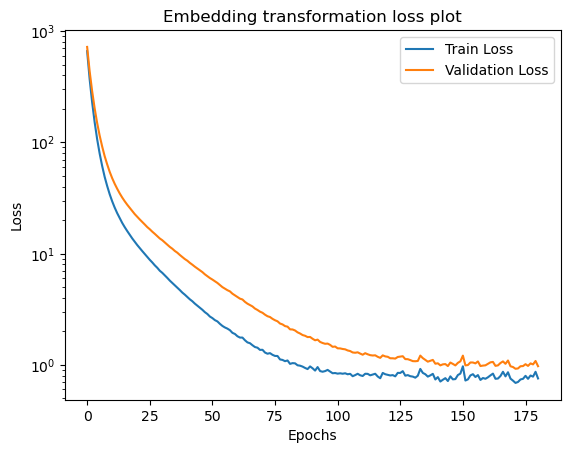

In [173]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Validation Loss")
plt.title("Embedding transformation loss plot")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()

In [ ]:
with open('transformation_matrix_glove.npy' , "wb") as f:
    np.save(f, W.detach().cpu().numpy())

In [ ]:
pandas.DataFrame({"train losses": [float(x) for x in train_losses], "test losses": [float(x) for x in test_losses]}).to_csv("glove_losses.csv")

,train losses,test losses
0,661.457764,721.385193
1,370.543579,435.966644
2,228.822601,288.319244
3,151.752701,202.335526
4,106.731163,149.234955
...,...,...
176,0.747361,0.976879
177,0.800625,1.029041
178,0.782359,1.007839
179,0.864691,1.082132


: 

In [ ]:

with open('transformation_matrix_glove.npy' , "wb") as f:
    np.save(f, W.detach().cpu().numpy())

In [ ]:
text = "<2en>羅漢係我兄弟，他成日在正午放風箏，就算天陰陰"
#translation_token = get_madlad_embedding(text)

token_embeddings = []
for t in tokenizer(text)['input_ids']:
    #print(t)
    if tokenizer.decode(t) in glove_model.keys():
        #print(1)
        token_embedding = torch.tensor(glove_model[tokenizer.decode(t)] / glove_norm @ transformation_matrix).unsqueeze(0) * madlad_norm
    else:
        #print(2)
        token_embedding = get_madlad_embedding_layer(1)[t].unsqueeze(0)
        
    token_embeddings.append(torch.Tensor(token_embedding))
print(token_embeddings)
token_embeddings = torch.tensor(np.array([x.detach().cpu().numpy() for x in token_embeddings]))#.permute(1,0,2)

In [ ]:
out = model.generate(inputs_embeds=token_embeddings)
tokenizer.decode(out[0], skip_special_tokens=True)